# Recession Prediction Using Yield Curve Factors

Introduction

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [2]:
# Initialize global variables

# Load formatted data
y = pd.read_csv(r"files\data\f_USREC.csv").set_index("date").values
yc_data = pd.read_csv(r"files\data\f_YC-rates-1990-2023.csv").set_index("date")
cols = yc_data.columns.tolist()
X = yc_data.values
print(cols)

['3 mo', '6 mo', '1 yr', '2 yr', '3 yr', '5 yr', '7 yr', '10 yr']


## Principal Component Analysis
Text

In [6]:
# Standardize the data 
scaler = StandardScaler() 
X_f = scaler.fit_transform(X) 

# Apply PCA 
pca = PCA(n_components=3) 
X_pca = pca.fit_transform(X_f) 

# Compute percentage of variance explained for each component 
eigvals = np.round(pca.explained_variance_ratio_ * 100, decimals=2) 

# Compute eigenvector loadings 
eigvecs = pca.components_

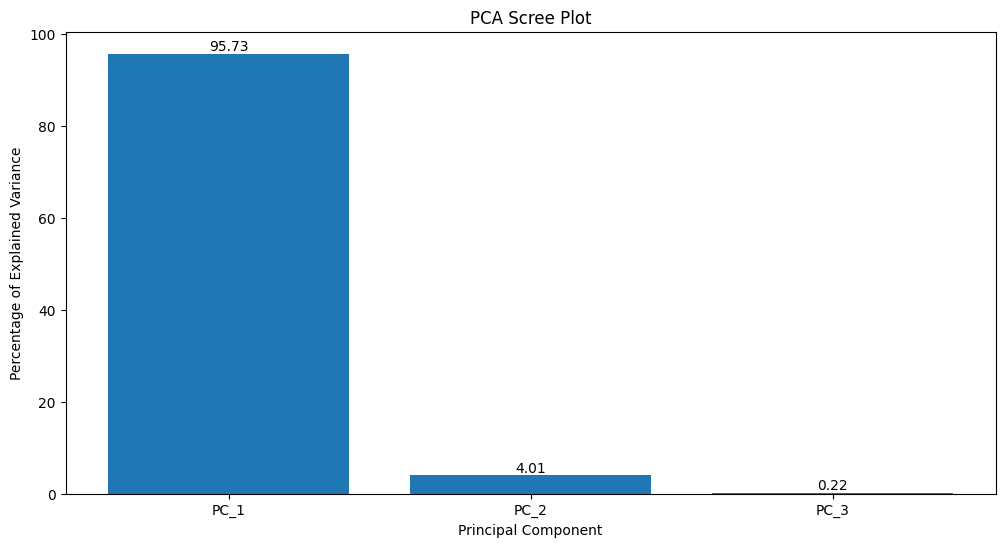

In [7]:
# Visualize percentage explained by eigenvalues
plt.figure(figsize=(12, 6))
labels = []
for i in range(1, len(eigvals) + 1):
    labels.append("PC_" + str(i))

bars = plt.bar(x=range(1, len(eigvals) + 1), height=eigvals, tick_label=labels)

for bar in bars:
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
             f'{bar.get_height():.2f}', ha='center', va='bottom')

plt.ylabel("Percentage of Explained Variance")
plt.xlabel("Principal Component")
plt.title("PCA Scree Plot")
plt.show()

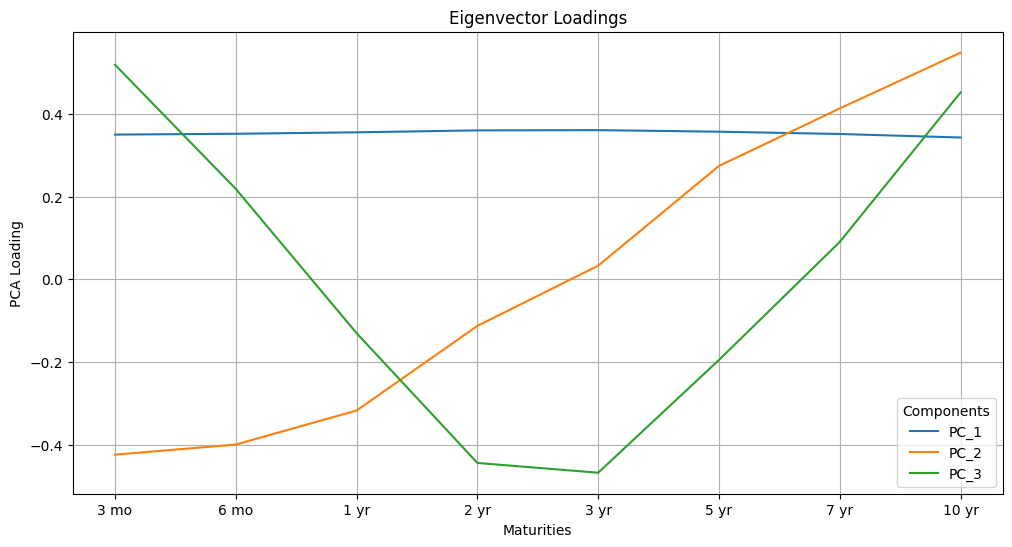

In [8]:
# Visualize eigenvector loadings
plt.figure(figsize=(12, 6))
for j in range(len(eigvecs)):
    plt.plot(eigvecs[j], label=labels[j])

plt.xticks(range(len(eigvecs[0])), cols)
plt.legend(title="Components")
plt.ylabel("PCA Loading")
plt.xlabel("Maturities")
plt.title("Eigenvector Loadings")
plt.grid()
plt.show()

Interpreting the components